In [1]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [2]:
import pandas as pd
import numpy as np


In [5]:
columnnames = ['sepal length in cm','sepal width in cm','petal length in cm','petal width in cm','class']
iris_df = pd.read_csv('iris.data', names=columnnames)

In [9]:
print(iris_df.ix[np.random.random_integers(0, len(iris_df), 10)])

     sepal length in cm  sepal width in cm  petal length in cm  \
12                  4.8                3.0                 1.4   
91                  6.1                3.0                 4.6   
84                  5.4                3.0                 4.5   
77                  6.7                3.0                 5.0   
35                  5.0                3.2                 1.2   
111                 6.4                2.7                 5.3   
77                  6.7                3.0                 5.0   
52                  6.9                3.1                 4.9   
84                  5.4                3.0                 4.5   
9                   4.9                3.1                 1.5   

     petal width in cm            class  
12                 0.1      Iris-setosa  
91                 1.4  Iris-versicolor  
84                 1.5  Iris-versicolor  
77                 1.7  Iris-versicolor  
35                 0.2      Iris-setosa  
111                1.

## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [10]:
#Checking for missing values
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
class                 150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [15]:
#Checking for 0 value in all features (0 value not missing value. Sepal and petal dimensions cant be 0)
print('Number of 0 values in feature - sepal length in cm is',len(iris_df[iris_df['sepal length in cm'] == 0]))
print('Number of 0 values in feature - sepal width in cm is',len(iris_df[iris_df['sepal width in cm'] == 0]))
print('Number of 0 values in feature - petal length in cm is',len(iris_df[iris_df['petal length in cm'] == 0]))
print('Number of 0 values in feature - petal width in cm is',len(iris_df[iris_df['petal width in cm'] == 0]))

Number of 0 values in feature - sepal length in cm is 0
Number of 0 values in feature - sepal width in cm is 0
Number of 0 values in feature - petal length in cm is 0
Number of 0 values in feature - petal width in cm is 0


## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [23]:
iris_df['class'] = iris_df['class'].replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})

In [30]:
iris_df['class'].unique()

array([0, 1, 2])

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [31]:
iris_df.corr()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
sepal length in cm,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal width in cm,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal length in cm,0.871754,-0.420516,1.000000,0.962757,0.949043
petal width in cm,0.817954,-0.356544,0.962757,1.000000,0.956464
class,0.782561,-0.419446,0.949043,0.956464,1.000000


In [ ]:
#sepal length in cm has a correlation of 0.782561 with target vairable 'class' Cannot be dropped
#sepal width in cm has a correlation of -0.419446 with target vairable 'class' Cannot be dropped
#petal length in cm has a correlation of 0.949043 with target vairable 'class' Cannot be dropped
#petal width in cm has a correlation of 0.956464 with target vairable 'class' Cannot be dropped

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [33]:
print(iris_df['sepal length in cm'].var())
print(iris_df['sepal width in cm'].var())
print(iris_df['petal length in cm'].var())
print(iris_df['petal width in cm'].var())

0.6856935123042505
0.18800402684563763
3.1131794183445156
0.5824143176733784


In [ ]:
#All independent variables have variance > 0.1 Cannot drop any independent variable

## Question 6

*Plot the scatter matrix for all the variables.*

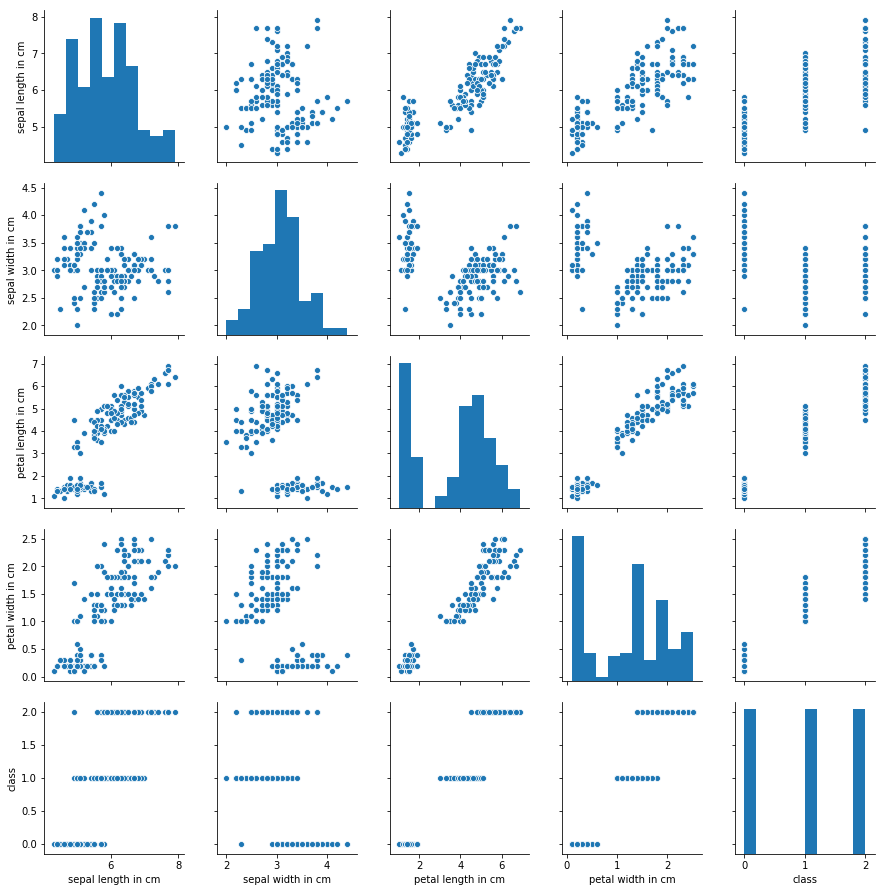

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.pairplot(iris_df)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.model_selection import train_test_split

In [38]:
X = iris_df.drop("class", axis=1)
y = iris_df["class"]

In [39]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [40]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
#Since all data is in cm, we need not apply zscore to bring all values to scale
NNH = KNeighborsClassifier(n_neighbors=3)

In [55]:
NNH.fit(X_train,y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=3, p=2,
           weights='uniform')

In [56]:
predicted_labels1 = NNH.predict(X_test)

In [92]:
print('The accuracy score at k=3 is',accuracy_score(y_test, predicted_labels1))

The accuracy score at k=3 is 0.9


In [93]:
NNH = KNeighborsClassifier(n_neighbors=5)
NNH.fit(X_train,y_train)
predicted_labels2 = NNH.predict(X_test)
print('The accuracy score at k=5 is',accuracy_score(y_test, predicted_labels2))

The accuracy score at k=5 is 0.9


In [94]:
NNH = KNeighborsClassifier(n_neighbors=7)
NNH.fit(X_train,y_train)
predicted_labels3 = NNH.predict(X_test)
print('The accuracy score at k=7 is',accuracy_score(y_test, predicted_labels3))

The accuracy score at k=7 is 0.8666666666666667


In [79]:
NNH = KNeighborsClassifier(n_neighbors=1)
NNH.fit(X_train,y_train)
predicted_labels3 = NNH.predict(X_test)
accuracy = accuracy_score(y_test, predicted_labels3)

0.09999999999999998

## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [95]:
for i in np.arange(1,20,2):
    NNH = KNeighborsClassifier(n_neighbors=i)
    NNH.fit(X_train,y_train)
    predicted_labels = NNH.predict(X_test)
    print('The Mis Classification error score at k=',i,'is',1-accuracy_score(y_test, predicted_labels))

The Mis Classification error score at k= 1 is 0.09999999999999998
The Mis Classification error score at k= 3 is 0.09999999999999998
The Mis Classification error score at k= 5 is 0.09999999999999998
The Mis Classification error score at k= 7 is 0.1333333333333333
The Mis Classification error score at k= 9 is 0.09999999999999998
The Mis Classification error score at k= 11 is 0.09999999999999998
The Mis Classification error score at k= 13 is 0.09999999999999998
The Mis Classification error score at k= 15 is 0.09999999999999998
The Mis Classification error score at k= 17 is 0.09999999999999998
The Mis Classification error score at k= 19 is 0.09999999999999998


## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

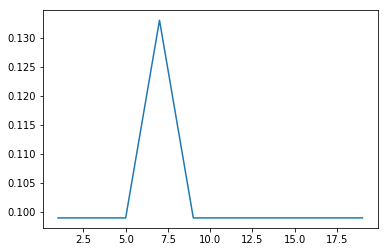

In [101]:
import matplotlib.pyplot as plt
plt.plot([1,3,5,7,9,11,13,15,17,19], [0.099,0.099,0.099,0.133,0.099,0.099,0.099,0.099,0.099,0.099])
plt.show()

# Naive Bayes with Iris Data

In [102]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [103]:
X = iris_df.drop(labels= "class" , axis = 1)
y = iris_df['class']

In [104]:
#Check the dataset
print(y)
print(X)

0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21     0
22     0
23     0
24     0
25     0
26     0
27     0
28     0
29     0
      ..
120    2
121    2
122    2
123    2
124    2
125    2
126    2
127    2
128    2
129    2
130    2
131    2
132    2
133    2
134    2
135    2
136    2
137    2
138    2
139    2
140    2
141    2
142    2
143    2
144    2
145    2
146    2
147    2
148    2
149    2
Name: class, Length: 150, dtype: int64
     sepal length in cm  sepal width in cm  petal length in cm  \
0                   5.1                3.5                 1.4   
1                   4.9                3.0                 1.4   
2                   4.7                3.2                 1.3   
3                   4.6                3.1                 1.5   
4                   5.0                3.6                 1.4   
5               

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

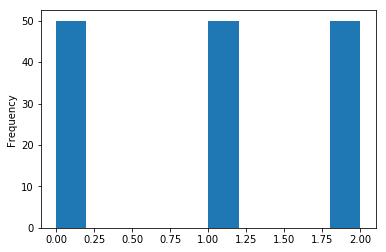

In [110]:
y.plot(kind='hist')
#Variable class has same frequency for class 0, 1 and 2

### Question 12 
Find Correlation among all variables and give your insights 

In [0]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [111]:
iris_df.corr()
#Sepal length has high correlation with petal length and petal width
#Petal length has high correlation with petal width
#We will ignore it here

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
sepal length in cm,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal width in cm,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal length in cm,0.871754,-0.420516,1.000000,0.962757,0.949043
petal width in cm,0.817954,-0.356544,0.962757,1.000000,0.956464
class,0.782561,-0.419446,0.949043,0.956464,1.000000


### Split data in Training and test set in 80:20.

In [117]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [0]:
# Use StandardScaler or similar methods

In [119]:
#All data is in same scale of cm. Scaling is not required, but doing it since its asked for in this question
#StandardScaler not taught in class. Using Zscore
from scipy.stats import zscore

In [120]:
#Applying zscore to df
X = zscore(X)

In [122]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


### Question 14 
Train and Fit NaiveBayes Model

In [124]:
model = GaussianNB()
model.fit(X_train, y_train)
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)


In [125]:
#Predict
predicted = model.predict(X_test)

In [129]:
predicted

array([2, 1, 0, 1, 1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 0, 1, 2,
       1, 1, 2, 2, 1, 1, 2, 2])

In [130]:
y_test

149    2
84     1
40     0
66     1
106    2
41     0
52     1
94     1
11     0
51     1
77     1
85     1
32     0
109    2
28     0
70     1
108    2
137    2
46     0
37     0
82     1
120    2
63     1
119    2
129    2
138    2
97     1
80     1
101    2
140    2
Name: class, dtype: int64

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [134]:
# show Confusion Matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
metrics.confusion_matrix(predicted, y_test)

array([[7, 0, 0],
       [0, 9, 2],
       [0, 3, 9]])

In [135]:
# show accuracy
accuracy_score(predicted,y_test)

0.8333333333333334

In [144]:
#Show precision and Recall metrics
precision_score(y_test, predicted, average='macro')

0.8560606060606061

In [146]:
recall_score(y_test, predicted, average='macro')

0.8560606060606061

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779